# Working with Climate Data

## Introduction

This tutorial shows, in detail, how to make a PyEarthTools pipeline for loading climate data. It is a precursor step to creating an ML model for bias correction. It goes into a lot of detail in order to document how to process new data sources and what steps are involved. The end result is a re-usable data loading pipeline, which can then be re-used for many projects, based on the steps and assumptions shown here.

In general terms, an "analysis" refers to estimates of current conditions, "reanalysis" refers to estimates of historical conditions, "nowcasting" refers to predictions of conditions which are expected in the next 90 minutes, "short term" refers to around 6-48 hours lead time and "weather" refers to 6 hours to 10 days lead time. A variety of terms like "multi-week", "sub-seasonal" and "seasonal" refer to the period from weeks to months. Lead times longer than a few months may be referred to as "seasonal" and merge into the climate time scales. Time scales for climate modelling are typically decades into the future or longer. These terms are not accepted universally, and some people may refer to any of these time scales as climate modelling. Within this tutorial, climate data is meant to describe predictions at least a year into the future.

A "reforecast" is done to generate "what the forecast would have been". It is subtly different to a "reanalysis", because it includes the lead time component as well as the estimate at a point in time.

Climate data uses non-Gregorian calendars, which also involve the use of date/time libraries which may be unfamiliar to many users. 

This tutorial will demonstrate the loading of climate data which includes both reforecasting outputs and predictions of the future, and merging it with reanalysis data for the purposes of validation of the reforecast component of the dataset.

This will involve loading a climate prediction run from CMIP5 and ERA5 reanalysis data.


In [1]:
import pyearthtools.data as petdata
import pyearthtools.pipeline as petpipe
import site_archive_nci

In [2]:
%%capture

# This builds an accessor that can be indexed by time, filtered according to the specified parameters
# Multiple institutions, scenarios and models are unsupported but the intention is to support that in future
# Models should generally be included in a pipeline of operations rather than used directly, but we will
# explore some of the functionality of this object regardless
cmip5_model1 = petdata.archive.CMIP5(institutions='BCC', scenarios=['rcp60'], models=['bcc-csm1-1'], interval='mon', variables='tas')

In [3]:
# With an exact time, you need to pick a time actually in the dataset, for fuzzy selection see the next cell

# Under-specifying the datetime will request all source data which matches Jan 2010
# In this case, the data is monthy, with a pseudo-day-of-month of the 16th of the month
# Note for later - longitude is indexed from 0 to 360
ds_cmip_2010 = cmip5_model1['2010-01']  # Query data along primary dimension
ds_cmip_2010

In [4]:
# Here we show how to request a two-year data period. This is not the normal method
# for data access for the end-to-end example, but can be used to simply retrieve data
two_years_of_cmip = cmip5_model1.series(start='2010-01-01', end='2012-01-01', interval = (1, 'month'))
two_years_of_cmip

<xarray.Dataset> Size: 862kB
Dimensions:    (time: 24, bnds: 2, lat: 64, lon: 128)
Coordinates:
  * time       (time) object 192B 2010-01-16 12:00:00 ... 2011-12-16 12:00:00
  * lat        (lat) float64 512B -87.86 -85.1 -82.31 ... 82.31 85.1 87.86
  * lon        (lon) float64 1kB 0.0 2.812 5.625 8.438 ... 351.6 354.4 357.2
    height     float64 8B 2.0
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) object 384B dask.array<chunksize=(24, 2), meta=np.ndarray>
    lat_bnds   (time, lat, bnds) float64 25kB dask.array<chunksize=(24, 64, 2), meta=np.ndarray>
    lon_bnds   (time, lon, bnds) float64 49kB dask.array<chunksize=(24, 128, 2), meta=np.ndarray>
    tas        (time, lat, lon) float32 786kB dask.array<chunksize=(24, 64, 128), meta=np.ndarray>
Attributes: (12/24)
    institution:            Beijing Climate Center(BCC),China Meteorological ...
    institute_id:           BCC
    experiment_id:          rcp60
    source:                 bcc-csm1-1:atmosphere:  BCC_AGCM2.1 (T42L26); lan...
    model_id:               bcc-csm1-1
    forcing:                Nat Ant GHG SD Oz Sl SS Ds BC OC
    ...                     ...
    table_id:               Table Amon (11 April 2011) 1cfdc7322cf2f4a3261482...
    title:                  bcc-csm1-1 model output prepared for CMIP5 RCP6
    parent_experiment:      historical
    modeling_realm:         atmos
    realization:            1
    cmor_version:           2.5.6

In [5]:
# Here we create an ERA5 accessor. When we pass the same year and date in, this time around
# we get 744 time-steps, due to the increased time resolution of ERA5. In order to relate
# ERA5 to CMIP, we will need to deal with this temporal mismatch. They also have different
# spatial grids. We'll look at how to do that next.
era5 = petdata.archive.ERA5('2t',)
era5['2010-01']  # Uncomment this line to see the returned dataset

<xarray.Dataset> Size: 6GB
Dimensions:    (longitude: 1440, latitude: 721, time: 744)
Coordinates:
  * longitude  (longitude) float32 6kB -180.0 -179.8 -179.5 ... 179.5 179.8
  * latitude   (latitude) float32 3kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * time       (time) datetime64[ns] 6kB 2010-01-01 ... 2010-01-31T23:00:00
Data variables:
    2t         (time, latitude, longitude) float64 6GB dask.array<chunksize=(93, 91, 180), meta=np.ndarray>
Attributes:
    Conventions:  CF-1.6
    history:      2020-09-28 12:42:00 UTC+1000 by era5_replication_tools-1.2....
    license:      Licence to use Copernicus Products: https://apps.ecmwf.int/...
    summary:      ERA5 is the fifth generation ECMWF atmospheric reanalysis o...
    title:        ERA5 single-levels reanalysis 2m_temperature 20100101-20100131

In [6]:
# In this case, we are lucky, and ERA5 actually has a monthly-average product on disk already
# With this small change, we can ensure we're working with temporally matched data
# Note for later - longitude is indexed from -180 to + 180
era5 = petdata.archive.ERA5('2t', product='monthly-averaged')
era5['2010-01']  # Uncomment this line to see the returned dataset

<xarray.Dataset> Size: 8MB
Dimensions:    (longitude: 1440, latitude: 721, time: 1)
Coordinates:
  * longitude  (longitude) float32 6kB -180.0 -179.8 -179.5 ... 179.5 179.8
  * latitude   (latitude) float32 3kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * time       (time) datetime64[ns] 8B 2010-01-01
Data variables:
    2t         (time, latitude, longitude) float64 8MB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
Attributes:
    Conventions:  CF-1.6
    history:      2020-09-05 13:01:05 UTC+1000 by era5_replication_tools-1.0....
    license:      Licence to use Copernicus Products: https://apps.ecmwf.int/...
    summary:      ERA5 is the fifth generation ECMWF atmospheric reanalysis o...
    title:        ERA5 single-levels monthly-averaged 2m_temperature 20100101...

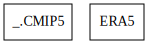

In [7]:
pipe = petpipe.Pipeline(
    (cmip5_model1, era5),
    )
pipe

In [8]:
# Here we can draw matched time steps from CMIP5 and ERA5 
# There are still some problems to iron out, but things are getting closer
pipe['2010-01']  # Uncomment this line to see a simple use of the pipeline so far

# The problems which remain are:
# - The climate data is in a 'noleap' calendar whereas ERA5 uses familiar date-time indexing
# - The variables are in a different order in the two objects (time,lat,lon,height) vs (lon,lat,time) assumed to be at the surface
# - ERA5 is still much higher spatial resolution than the CMIP data, so the lat/lon grids still need to be matched
# - The actual latitudes and longitudes may not match nicely and a bit of interpolation might be needed

(<xarray.Dataset> Size: 37kB
 Dimensions:    (time: 1, bnds: 2, latitude: 64, longitude: 128)
 Coordinates:
   * time       (time) object 8B 2010-01-16 12:00:00
   * latitude   (latitude) float64 512B -87.86 -85.1 -82.31 ... 82.31 85.1 87.86
   * longitude  (longitude) float64 1kB 0.0 2.812 5.625 ... 351.6 354.4 357.2
     height     float64 8B 2.0
 Dimensions without coordinates: bnds
 Data variables:
     time_bnds  (time, bnds) object 16B dask.array<chunksize=(1, 2), meta=np.ndarray>
     lat_bnds   (time, latitude, bnds) float64 1kB dask.array<chunksize=(1, 64, 2), meta=np.ndarray>
     lon_bnds   (time, longitude, bnds) float64 2kB dask.array<chunksize=(1, 128, 2), meta=np.ndarray>
     tas        (time, latitude, longitude) float32 33kB dask.array<chunksize=(1, 64, 128), meta=np.ndarray>
 Attributes: (12/24)
     institution:            Beijing Climate Center(BCC),China Meteorological ...
     institute_id:           BCC
     experiment_id:          rcp60
     source:            

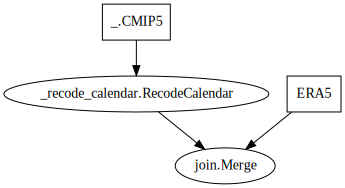

In [9]:
# Before all tackling those issues, we're going to look a bit more at how PyEarthTools can be used to relate
# the data sources to produce input data for a machine learning model
# The basic goal is to define all the operations needed so that at the end of the day, it's easy
# to pull samples off an end-to-end pipeline, either by date/time (most common) or by another simple index (less common)

# Here we start by producing a pipeline which partly tackles the calendar issue
# and merges the two data sources into a single in-memory object, in this case 
# an xarray Dataset

pipe = petpipe.Pipeline(
    cmip5_model1,
    (petpipe.operations.xarray.RecodeCalendar(), era5),
    petpipe.operations.xarray.Merge()
)
pipe

In [10]:
%%capture
# # Turn off debugging output, which reports the risks involved with recoding the calendar
# # and may produce some dask performance warnings

sample = pipe['2010-01'] 

In [11]:
sample

<xarray.Dataset> Size: 29MB
Dimensions:    (time: 2, latitude: 785, longitude: 1552, bnds: 2)
Coordinates:
  * time       (time) datetime64[ns] 16B 2010-01-01 2010-01-16T12:00:00
  * latitude   (latitude) float64 6kB -90.0 -89.75 -89.5 ... 89.5 89.75 90.0
  * longitude  (longitude) float64 12kB -180.0 -179.8 -179.5 ... 354.4 357.2
    height     float64 8B 2.0
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) object 32B dask.array<chunksize=(1, 2), meta=np.ndarray>
    lat_bnds   (time, latitude, bnds) float64 25kB dask.array<chunksize=(1, 64, 2), meta=np.ndarray>
    lon_bnds   (time, longitude, bnds) float64 50kB dask.array<chunksize=(1, 128, 2), meta=np.ndarray>
    tas        (time, latitude, longitude) float32 10MB dask.array<chunksize=(1, 64, 128), meta=np.ndarray>
    2t         (time, latitude, longitude) float64 19MB dask.array<chunksize=(1, 721, 1552), meta=np.ndarray>
Attributes: (12/24)
    institution:            Beijing Climate Center(BCC),China Meteorological ...
    institute_id:           BCC
    experiment_id:          rcp60
    source:                 bcc-csm1-1:atmosphere:  BCC_AGCM2.1 (T42L26); lan...
    model_id:               bcc-csm1-1
    forcing:                Nat Ant GHG SD Oz Sl SS Ds BC OC
    ...                     ...
    table_id:               Table Amon (11 April 2011) 1cfdc7322cf2f4a3261482...
    title:                  bcc-csm1-1 model output prepared for CMIP5 RCP6
    parent_experiment:      historical
    modeling_realm:         atmos
    realization:            1
    cmor_version:           2.5.6

This shows how a pipeline can be used to request all matching elements of each source according to month. The CMIP calendar has been recoded, but there is still a mismatch between the two different monthly values. The CMIP data in this example nominally has a day-of-month of the 16th of each month (e.g. 2010-01-16) whereas the ERA5 calendar chooses the start of the month (e.g. 2010-01-01). This introduces a lot of uncertainty to users. Does this mean the ERA5 averaging window is actually from the middle of one month to the middle of the next, centered on the first of the month? Or is it the rest of the month specified? A misinterpretation here could result in a temporal error of up to a fornight between the data sources. It is necessary to consult the data dictionary for the data source to determine what applies. Nuances like this are why it's a good idea for the community to encode standard loading pipelines into open source tools, so that newcomers (or people who might simply overlook the issue) can rely on standardised routines.

In this case, both of these averages are actually for the same time period, being all of January 2010. We could just bake a translation into the data loading, but perhaps someone will come up with some other dataset or use case where the assumption isn't valid. As a result, we will make the translation explicit by adding another operation, just like the calendar recode step.

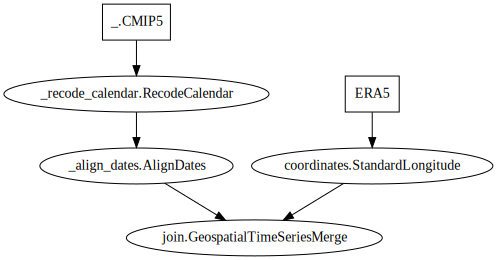

In [12]:
pipe1 = petpipe.Pipeline(
    cmip5_model1,
    petpipe.operations.xarray.RecodeCalendar(),
    petpipe.operations.xarray.AlignDates(to="start_of_month"),    
)

pipe2 = petpipe.Pipeline(
    era5,
    petdata.transforms.coordinates.StandardLongitude(type="0-360"),   
    
)

pipe3 = petpipe.Pipeline(
    (pipe1, pipe2),
    petpipe.operations.xarray.join.GeospatialTimeSeriesMerge(reference_index=0)
)

pipe3

In [13]:
%%capture
# Turn off debugging output, which reports the risks involved with recoding the calendar
# and may produce some dask performance warnings

sample = pipe3['2010-01']

In [14]:
sample

<xarray.Dataset> Size: 103kB
Dimensions:    (time: 1, latitude: 64, bnds: 2, longitude: 128)
Coordinates:
    height     float64 8B 2.0
  * latitude   (latitude) float64 512B -87.86 -85.1 -82.31 ... 82.31 85.1 87.86
  * longitude  (longitude) float64 1kB 0.0 2.812 5.625 ... 351.6 354.4 357.2
  * time       (time) datetime64[ns] 8B 2010-01-01
Dimensions without coordinates: bnds
Data variables:
    lat_bnds   (time, latitude, bnds) float64 1kB dask.array<chunksize=(1, 64, 2), meta=np.ndarray>
    lon_bnds   (time, longitude, bnds) float64 2kB dask.array<chunksize=(1, 128, 2), meta=np.ndarray>
    tas        (time, latitude, longitude) float32 33kB dask.array<chunksize=(1, 64, 128), meta=np.ndarray>
    time_bnds  (time, bnds) object 16B dask.array<chunksize=(1, 2), meta=np.ndarray>
    2t         (time, latitude, longitude) float64 66kB dask.array<chunksize=(1, 64, 128), meta=np.ndarray>
Attributes: (12/24)
    institution:            Beijing Climate Center(BCC),China Meteorological ...
    institute_id:           BCC
    experiment_id:          rcp60
    source:                 bcc-csm1-1:atmosphere:  BCC_AGCM2.1 (T42L26); lan...
    model_id:               bcc-csm1-1
    forcing:                Nat Ant GHG SD Oz Sl SS Ds BC OC
    ...                     ...
    table_id:               Table Amon (11 April 2011) 1cfdc7322cf2f4a3261482...
    title:                  bcc-csm1-1 model output prepared for CMIP5 RCP6
    parent_experiment:      historical
    modeling_realm:         atmos
    realization:            1
    cmor_version:           2.5.6

Aligning the dates mean that the merged pipeline samples can use a common index. When the dates were aligned, the variable sorting issue also disappeared, because xarray could now see how to match the variables across the sources more effectively. It is possible to control the sort order of variables in an array, but it is not necessary here any longer.

The final issue pertains to the grid resolution of the two datasets. Let's do some plotting to make it clearer.

The problems which remain are:
- ERA5 is still much higher spatial resolution than the CMIP data, so the lat/lon grids still need to be matched
- The actual latitudes and longitudes may not match nicely and a bit of interpolation might be needed

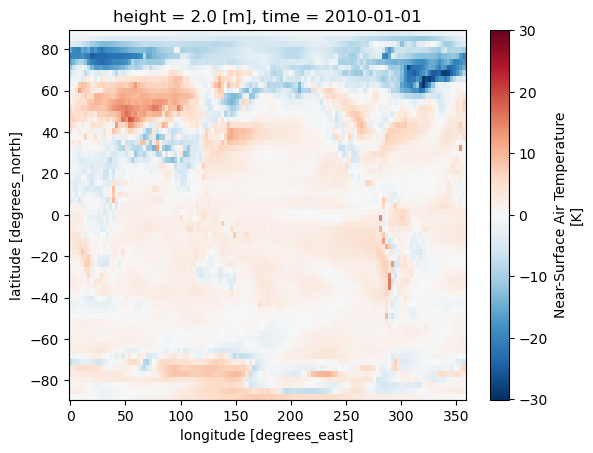

In [15]:
bias = sample['tas'] - sample['2t']
bias.plot()